## 1. Import required Libraries

In [1]:
import pandas as pd
#for data loading,cleaning,analysis.

import numpy as np
#for arrays and mathematical operations

import matplotlib.pyplot as plt
#used for plotting charts

import seaborn as sns

from sklearn.model_selection import train_test_split
#to split your dataset into training and testing sets.

from sklearn.preprocessing import LabelEncoder
#converts categorical text labels into numeric values.

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
#To evaluate ML model

from sklearn.ensemble import RandomForestClassifier
#Imports the RandomForestClassifier algorithm

import joblib


# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline


## 2. Load Data

In [2]:
df=pd.read_csv("e-commerce.csv")

In [3]:
df.head()

,ROW ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Profit,Order Priority,Order Year,Order Month,Order Day,Ship Year,Ship Month,Ship Day,Delivery Time,Cost
0,34323,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,762.1845,Critical,2012,7,31,2012,7,31,0,613.8955
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,-288.7650,Critical,2013,2,5,2013,2,7,2,3074.5300
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,919.9710,Medium,2013,10,17,2013,10,18,1,3339.7100
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,-96.5400,Medium,2013,1,28,2013,1,30,2,2078.8900
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,311.5200,Critical,2013,11,5,2013,11,6,1,1618.4000


## 3. Data Cleaning

In [4]:
#Below mentioned coluns are non-informative features.
#Dropping them because they are unique identifiers or text labels that do not contribute to predicting Order Priority.
#Keeping them would Increase computation,Reduce accuracy or Cause overfitting.

In [5]:
#df["Order Date"] = pd.to_datetime(df["Order Date"])

In [6]:
#df["Order_Day"] = df["Order Date"].dt.day

In [7]:
df = df.drop(["ROW ID","Order Date", "Ship Date","Customer ID", "Customer Name","Product ID", "Product Name"], axis=1)

In [8]:
df.columns

Index(['Order ID', 'Ship Mode', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Shipping Cost', 'Profit', 'Order Priority', 'Order Year',
       'Order Month', 'Order Day', 'Ship Year', 'Ship Month', 'Ship Day',
       'Delivery Time', 'Cost'],
      dtype='object')

## 4. Label Encode the Target

In [9]:
#Encoding categorical columns because ML models cannot understand text as they only work with numbers.

In [10]:
df["Order Priority"].value_counts()

Order Priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64

In [11]:
target_le = LabelEncoder()
df["Order Priority"] = target_le.fit_transform(df["Order Priority"])

In [12]:
df["Order Priority"].value_counts()

Order Priority
3    29433
1    15501
0     3932
2     2424
Name: count, dtype: int64

In [13]:
df["Order Priority"].head()

0    0
1    0
2    3
3    3
4    0
Name: Order Priority, dtype: int64

## 5. Encode Categorical Features

In [14]:
# #List the categorical columns
cat_cols = df.select_dtypes(include=['object','string']).columns
cat_cols

Index(['Order ID', 'Ship Mode', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Category', 'Sub-Category'],
      dtype='object')

In [15]:
# #Converting each catagorical value into a unique number.
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  

In [16]:
df.head()

,Order ID,Ship Mode,Segment,City,State,Country,Market,Region,Category,Sub-Category,...,Profit,Order Priority,Order Year,Order Month,Order Day,Ship Year,Ship Month,Ship Day,Delivery Time,Cost
0,1499,1,0,2290,703,139,6,6,2,0,...,762.1845,0,2012,7,31,2012,7,31,0,613.8955
1,13063,2,1,3518,702,6,0,9,0,5,...,-288.7650,0,2013,2,5,2013,2,7,2,3074.5300
2,12983,0,0,497,820,6,0,9,2,13,...,919.9710,3,2013,10,17,2013,10,18,1,3339.7100
3,6813,0,2,375,145,47,4,3,2,13,...,-96.5400,3,2013,1,28,2013,1,30,2,2078.8900
4,21702,1,0,857,270,110,1,0,2,6,...,311.5200,0,2013,11,5,2013,11,6,1,1618.4000


## 6. Split Features (X) & Target (y)

In [17]:
#Dropping Order Priority as it is a target column(y)
X = df.drop("Order Priority", axis=1)
X.columns

Index(['Order ID', 'Ship Mode', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Shipping Cost', 'Profit', 'Order Year', 'Order Month',
       'Order Day', 'Ship Year', 'Ship Month', 'Ship Day', 'Delivery Time',
       'Cost'],
      dtype='object')

In [18]:
y = df["Order Priority"]
y.head()

0    0
1    0
2    3
3    3
4    0
Name: Order Priority, dtype: int64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
y_train

2558     1
15041    3
38072    1
15694    3
30044    3
        ..
11284    0
44732    1
38158    3
860      0
15795    1
Name: Order Priority, Length: 41032, dtype: int64

## 7. Train the Machine Learning Model

In [21]:
# Why random forest?
# Great with mixed data,Requires little preprocessing, 
# Works Well With Large Feature Sets,helps generate feature importance plot

In [22]:
# #Create a Random Forest model with 200 decision trees. Deafult is 100.
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8. Evaluate the Model Performance

In [23]:
y_pred = model.predict(X_test)
#y_pred = y_pred.flatten()

In [24]:
y_pred

array([3, 1, 3, ..., 3, 1, 3], shape=(10258,))

In [25]:
comparison =pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]
print(comparison.head())

       Actual  Predicted  Difference
49728       3          3           0
45547       1          1           0
15664       3          3           0
40561       3          3           0
49426       3          3           0


In [26]:
# Convert encoded predictions back to original labels
y_pred_labels = le.inverse_transform(y_pred)
y_pred_labels

array(['Binders', 'Appliances', 'Binders', ..., 'Binders', 'Appliances',
       'Binders'], shape=(10258,), dtype=object)

In [27]:
# Convert actual encoded values back to original labels
y_test_labels = le.inverse_transform(y_test)
y_test_labels

array(['Binders', 'Appliances', 'Binders', ..., 'Binders', 'Accessories',
       'Appliances'], shape=(10258,), dtype=object)

In [28]:
# side by side comparison of actual value and predicted value
comparison_df = pd.DataFrame({
    "Actual": y_test_labels,
    "Predicted": y_pred_labels
})

comparison_df.head()

,Actual,Predicted
0,Binders,Binders
1,Appliances,Appliances
2,Binders,Binders
3,Binders,Binders
4,Binders,Binders


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7834860596607526

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.48      0.61       822
           1       0.69      0.70      0.69      3040
           2       0.98      0.41      0.58       481
           3       0.82      0.90      0.86      5915

    accuracy                           0.78     10258
   macro avg       0.83      0.62      0.69     10258
weighted avg       0.79      0.78      0.78     10258



## 9. Feature Importance

In [30]:
#Feature importances gives the importance score of each input feature used by the Random Forest.
#Shows which features contribute most to predicting the target (Order Priority).

In [31]:
importances = model.feature_importances_
importances

array([0.05449756, 0.04445254, 0.01326661, 0.05286106, 0.04757592,
       0.03202479, 0.01553565, 0.02423023, 0.00944973, 0.02850052,
       0.08085715, 0.02503302, 0.01751706, 0.12483184, 0.05488927,
       0.01457811, 0.02944624, 0.04116675, 0.01526263, 0.02917072,
       0.04041529, 0.12893159, 0.07550571])

In [32]:
feature_names = X.columns
feature_names

Index(['Order ID', 'Ship Mode', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity',
       'Discount', 'Shipping Cost', 'Profit', 'Order Year', 'Order Month',
       'Order Day', 'Ship Year', 'Ship Month', 'Ship Day', 'Delivery Time',
       'Cost'],
      dtype='object')

In [33]:
type(importances)

numpy.ndarray

In [34]:
type(feature_names)

pandas.core.indexes.base.Index

In [35]:
# Convert feature names and importances into numpy arrays as both of them are of diffrent datatypes.
# Make their datatype even and prevent any mismatch error.
# Sorting becomes easier and also Matplotlib works best with NumPy arrays.
importances = np.array(importances)
feature_names = np.array(feature_names)

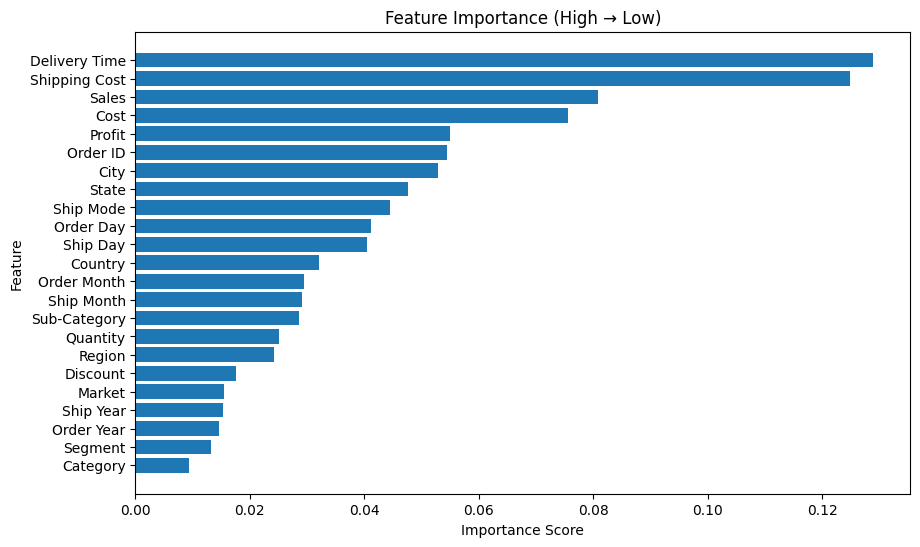

In [36]:
# Sort importances in descending order
sorted_idx = np.argsort(importances)[::-1]

# Sort both arrays
sorted_importances = importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance (High → Low)")
plt.gca().invert_yaxis()   # Highest at top
plt.show()

In [37]:
#Based on the Graph, Delivery Time is the strongest predictor.

In [38]:
# Calculate percentage contribution
percent_importance = (importances / importances.sum()) * 100

# Create DataFrame
feature_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance (%)": percent_importance
})

# Sort highest → lowest
feature_table = feature_table.sort_values(by="Importance (%)", ascending=False)

# Round values
feature_table["Importance (%)"] = feature_table["Importance (%)"].round(2)

# Display table
feature_table.head()

,Feature,Importance (%)
21,Delivery Time,12.89
13,Shipping Cost,12.48
10,Sales,8.09
22,Cost,7.55
14,Profit,5.49


## 10. Model Evaluation through Visuals

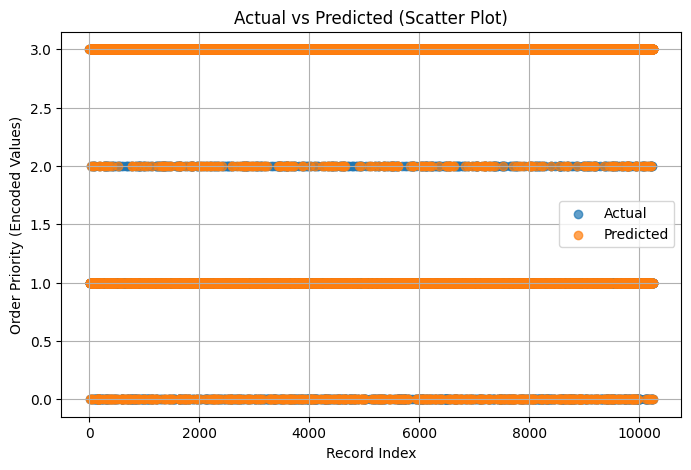

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.xlabel("Record Index")
plt.ylabel("Order Priority (Encoded Values)")
plt.title("Actual vs Predicted (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.show()

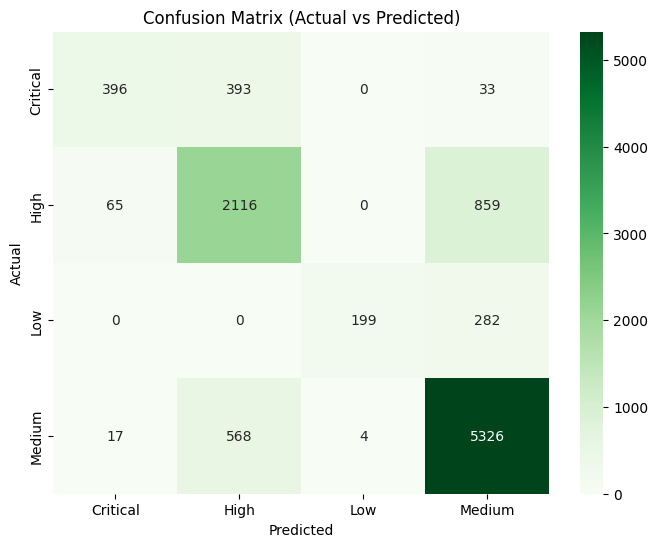

In [58]:
original_labels =target_le.classes_
y_test_text = target_le.inverse_transform(y_test)
y_pred_text = target_le.inverse_transform(y_pred)
labels_text = sorted(original_labels)  # strings

cm = confusion_matrix(y_test_text, y_pred_text, labels=labels_text)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels_text, yticklabels=labels_text)

plt.title("Confusion Matrix (Actual vs Predicted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\jonty\AppData\Local\Temp\ipykernel_5968\3564725438.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([comparison_df["Actual"], comparison_df["Predicted"]],


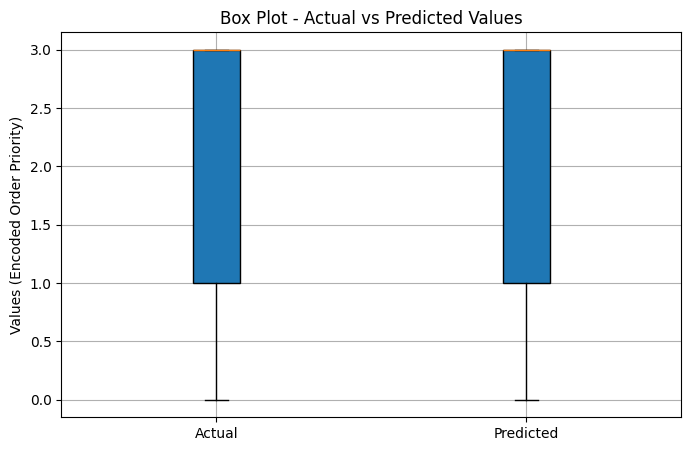

In [41]:
# Create a DataFrame for easy plotting
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

plt.figure(figsize=(8, 5))

# Draw boxplot for both columns
plt.boxplot([comparison_df["Actual"], comparison_df["Predicted"]],
            labels=["Actual", "Predicted"],
            patch_artist=True)

plt.title("Box Plot - Actual vs Predicted Values")
plt.ylabel("Values (Encoded Order Priority)")
plt.grid(True)
plt.show()

## 12. Save Model

In [43]:
# Save model + encoders + feature list
joblib.dump(model, "orderpriority_randomforest.pkl")
joblib.dump(target_le, "order_priority_target_encoder.pkl")
joblib.dump(encoders, "order_priority_feature_encoders.pkl")
joblib.dump(list(X.columns), "rf_feature_columns.pkl")

['rf_feature_columns.pkl']

## 13. Load Model

In [44]:
# model = joblib.load("orderpriority_randomforest.pkl")
# le = joblib.load("order_priority_re_encoder.pkl")